<a href="https://colab.research.google.com/github/SidraFarooqui/Pattern_Recognition/blob/main/SidraFarooqui_PatternRecognitionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install shap==0.43.0 xgboost==2.0.3   # uncomment in Colab

import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")
print(" All libraries imported successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.1/389.1 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 3.4 MB/s eta 0:00:00
✓ All libraries imported successfully


In [ ]:

df = pd.read_csv("amazon.csv")
print(f"Raw shape: {df.shape}")

# Strip currency symbols (₹) and percent signs
money = lambda s: float(re.sub(r"[^\d.]", "", str(s))) if pd.notnull(s) else np.nan
df["actual_price"]      = df["actual_price"].apply(money)
df["discounted_price"]  = df["discounted_price"].apply(money)
df["discount_percentage"] = (
    df["discount_percentage"].str.replace("%", "").astype(float)
)

Raw shape: (1465, 16)


In [ ]:

# Engineered discount features
# WHY THESE 4: Each captures a different aspect of the discount signal
#   - discount_percentage: relative markdown (from dataset)
#   - abs_discount: absolute savings in ₹ (matters more on cheap items)
#   - discount_ratio: sale price / original (normalized, bounded 0-1)
#   - log_price: log-compressed price (handles skewed distribution)
df["abs_discount"]   = df["actual_price"] - df["discounted_price"]
df["discount_ratio"] = df["discounted_price"] / df["actual_price"]
df["log_price"]      = np.log1p(df["actual_price"])

# Rating: coerce bad values (e.g. '|') then drop NaN
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"])

# Sentiment from star rating (NOT VADER — see note above)
df["sentiment"] = (df["rating"] >= 4.0).astype(int)

# Fill missing review text
df["review_content"] = df["review_content"].fillna("")

print(f"Clean shape: {df.shape}")
print(f"Rating stats:\n{df['rating'].describe().round(3)}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")
print(f"   {df['sentiment'].mean()*100:.1f}% positive")
print("\n Data loading and cleaning complete")


Clean shape: (1464, 20)
Rating stats:
count    1464.000
mean        4.097
std         0.292
min         2.000
25%         4.000
50%         4.100
75%         4.300
max         5.000
Name: rating, dtype: float64

Sentiment distribution:
sentiment
1    1110
0     354
Name: count, dtype: int64
  → 75.8% positive

 Data loading and cleaning complete


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit

NUM_COLS = ["discount_percentage", "abs_discount", "discount_ratio", "log_price"]
CAT_COLS = ["category"]

preprocess = ColumnTransformer(
    transformers=[
        ("txt", TfidfVectorizer(max_features=20_000, stop_words="english"),
         "review_content"),
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ]
)

# Group by product_id to prevent data leakage
groups = df["product_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=groups))
df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]

print(f"Train: {len(df_train)}  |  Test: {len(df_test)}")
print(f"Train sentiment: {df_train['sentiment'].value_counts().to_dict()}")
print(f"Test  sentiment: {df_test['sentiment'].value_counts().to_dict()}")
print("\n Preprocessing and split complete")


Train: 1178  |  Test: 286
Train sentiment: {1: 907, 0: 271}
Test  sentiment: {1: 203, 0: 83}

 Preprocessing and split complete


In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ridge baseline (combined: text + discount + category)
ridge = Pipeline([("prep", preprocess), ("reg", Ridge(alpha=1.0))])
ridge.fit(df_train, df_train["rating"])
y_pred_ridge = ridge.predict(df_test)

mae_ridge  = mean_absolute_error(df_test["rating"], y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(df_test["rating"], y_pred_ridge))

# Dummy baseline (predict mean)
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(df_train[NUM_COLS], df_train["rating"])
y_dummy = dummy_reg.predict(df_test[NUM_COLS])
mae_dummy = mean_absolute_error(df_test["rating"], y_dummy)

print("=" * 50)
print("E1-R: Rating Regression Baseline")
print("=" * 50)
print(f"Ridge MAE:  {mae_ridge:.3f}")
print(f"Ridge RMSE: {rmse_ridge:.3f}")
print(f"Dummy MAE:  {mae_dummy:.3f}")
print(f"Rating σ:   {df['rating'].std():.3f}")
print(f"\n Ridge reduces MAE by {(1 - mae_ridge/mae_dummy)*100:.0f}% vs. dummy baseline.")
print("Rating regression baseline complete")


E1-R: Rating Regression Baseline
Ridge MAE:  0.157
Ridge RMSE: 0.216
Dummy MAE:  0.212
Rating σ:   0.292

 Ridge reduces MAE by 26% vs. dummy baseline.
Rating regression baseline complete


E1-S: Sentiment Classification Baseline
SVC Macro-F1: 0.716
SVC Accuracy: 0.776

Dummy Acc:    0.710
Dummy F1:     0.415

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.54      0.58        83
    Positive       0.82      0.87      0.85       203

    accuracy                           0.78       286
   macro avg       0.73      0.71      0.72       286
weighted avg       0.77      0.78      0.77       286



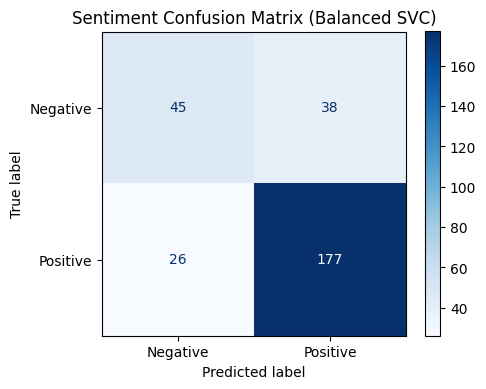

 Sentiment classification baseline complete


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (f1_score, accuracy_score,
                              classification_report, ConfusionMatrixDisplay)

svc = Pipeline([
    ("prep", preprocess),
    ("clf", LinearSVC(C=1, class_weight="balanced"))
])
svc.fit(df_train, df_train["sentiment"])
y_sent = svc.predict(df_test)

# Dummy baseline
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(df_train[NUM_COLS], df_train["sentiment"])
y_dummy_s = dummy_clf.predict(df_test[NUM_COLS])

print("=" * 50)
print("E1-S: Sentiment Classification Baseline")
print("=" * 50)
print(f"SVC Macro-F1: {f1_score(df_test['sentiment'], y_sent, average='macro'):.3f}")
print(f"SVC Accuracy: {accuracy_score(df_test['sentiment'], y_sent):.3f}")
print(f"\nDummy Acc:    {accuracy_score(df_test['sentiment'], y_dummy_s):.3f}")
print(f"Dummy F1:     {f1_score(df_test['sentiment'], y_dummy_s, average='macro'):.3f}")
print(f"\nDetailed Classification Report:")
print(classification_report(df_test["sentiment"], y_sent,
                             target_names=["Negative", "Positive"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    svc, df_test, df_test["sentiment"],
    display_labels=["Negative", "Positive"], cmap="Blues", ax=ax
)
ax.set_title("Sentiment Confusion Matrix (Balanced SVC)")
plt.tight_layout()
plt.show()
print(" Sentiment classification baseline complete")

In [ ]:

def make_reg_pipeline(use_text=True, use_num=True):
    """Build Ridge pipeline with selectable feature groups."""
    blocks = []
    if use_text:
        blocks.append(("txt", TfidfVectorizer(max_features=20_000,
                                               stop_words="english"),
                        "review_content"))
    if use_num:
        blocks.append(("num", StandardScaler(), NUM_COLS))
    blocks.append(("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS))
    return Pipeline([
        ("prep", ColumnTransformer(blocks)),
        ("reg", Ridge(alpha=1.0))
    ])

print("=" * 50)
print("E2: Rating Regression Ablation")
print("=" * 50)
ablation_reg = {}
for name, txt, num in [("Text-only", True, False),
                        ("Discount-only", False, True),
                        ("Combined", True, True)]:
    model = make_reg_pipeline(use_text=txt, use_num=num)
    model.fit(df_train, df_train["rating"])
    mae = mean_absolute_error(df_test["rating"], model.predict(df_test))
    ablation_reg[name] = mae
    print(f"  {name:<14} MAE: {mae:.3f}")

print(f"\n Combined ({ablation_reg['Combined']:.3f}) < "
      f"Text-only ({ablation_reg['Text-only']:.3f}) < "
      f"Discount-only ({ablation_reg['Discount-only']:.3f})")
print(f" Discount features add predictive signal beyond text alone.")
print("Rating ablation complete")


E2: Rating Regression Ablation
  Text-only      MAE: 0.169
  Discount-only  MAE: 0.172
  Combined       MAE: 0.157

 Combined (0.157) < Text-only (0.169) < Discount-only (0.172)
 Discount features add predictive signal beyond text alone.
Rating ablation complete


In [ ]:

def make_clf_pipeline(use_text=True, use_num=True):
    """Build balanced SVC pipeline with selectable feature groups."""
    blocks = []
    if use_text:
        blocks.append(("txt", TfidfVectorizer(max_features=20_000,
                                               stop_words="english"),
                        "review_content"))
    if use_num:
        blocks.append(("num", StandardScaler(), NUM_COLS))
    blocks.append(("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS))
    return Pipeline([
        ("prep", ColumnTransformer(blocks)),
        ("clf", LinearSVC(C=1, class_weight="balanced"))
    ])

print("=" * 50)
print("E2: Sentiment Classification Ablation  (answers RQ2)")
print("=" * 50)
ablation_clf = {}
for name, txt, num in [("Text-only", True, False),
                        ("Discount-only", False, True),
                        ("Combined", True, True)]:
    model = make_clf_pipeline(use_text=txt, use_num=num)
    model.fit(df_train, df_train["sentiment"])
    preds = model.predict(df_test)
    mf1 = f1_score(df_test["sentiment"], preds, average="macro")
    acc = accuracy_score(df_test["sentiment"], preds)
    ablation_clf[name] = (mf1, acc)
    print(f"  {name:<14} Macro-F1: {mf1:.3f}  Accuracy: {acc:.3f}")

print(f"\n Answer to RQ2: YES, adding pricing context improves sentiment prediction.")
print(" Sentiment ablation complete")

E2: Sentiment Classification Ablation  (answers RQ2)
  Text-only      Macro-F1: 0.700  Accuracy: 0.773
  Discount-only  Macro-F1: 0.702  Accuracy: 0.734
  Combined       Macro-F1: 0.716  Accuracy: 0.776

 Answer to RQ2: YES, adding pricing context improves sentiment prediction.
 Sentiment ablation complete


In [ ]:

from sklearn.model_selection import cross_val_score, GroupKFold

print("=" * 50)
print("5-Fold Grouped Cross-Validation (Ridge, Combined)")
print("=" * 50)

cv_preprocess = ColumnTransformer([
    ("txt", TfidfVectorizer(max_features=20_000, stop_words="english"),
     "review_content"),
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
cv_ridge = Pipeline([("prep", cv_preprocess), ("reg", Ridge(alpha=1.0))])

gkf = GroupKFold(n_splits=5)
cv_mae = cross_val_score(cv_ridge, df, df["rating"],
                          groups=df["product_id"],
                          scoring="neg_mean_absolute_error", cv=gkf)

print(f"Per-fold MAE: {[round(-s, 3) for s in cv_mae]}")
print(f"Mean MAE: {-cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"\n Low variance confirms results are stable, not due to lucky split.")
print("Cross-validation complete")


5-Fold Grouped Cross-Validation (Ridge, Combined)
Per-fold MAE: [np.float64(0.168), np.float64(0.163), np.float64(0.168), np.float64(0.176), np.float64(0.145)]
Mean MAE: 0.164 ± 0.010

 Low variance confirms results are stable, not due to lucky split.
Cross-validation complete


In [ ]:

from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import (HistGradientBoostingRegressor,
                               RandomForestClassifier)
from sklearn.base import TransformerMixin, BaseEstimator

class ToDense(BaseEstimator, TransformerMixin):
    """Convert sparse matrix to dense for tree-based models."""
    def fit(self, X, y=None): return self
    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

# Pre-transform once (avoids re-fitting preprocess for each model)
X_train_pre = preprocess.fit_transform(df_train)
X_test_pre  = preprocess.transform(df_test)

print("=" * 50)
print("E3: Rating Regression — Model Upgrades")
print("=" * 50)

# XGBoost (max_depth=3 instead of default 6 to reduce overfitting)
xgb_reg = XGBRegressor(
    n_estimators=400, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", random_state=42, n_jobs=-1
)
xgb_reg.fit(X_train_pre, df_train["rating"])
y_xgb = xgb_reg.predict(X_test_pre)
print(f"  XGBoost  MAE: {mean_absolute_error(df_test['rating'], y_xgb):.3f}"
      f"  RMSE: {np.sqrt(mean_squared_error(df_test['rating'], y_xgb)):.3f}")

# HistGradientBoosting (early stopping to prevent overfitting)
X_train_dense = ToDense().fit_transform(X_train_pre)
X_test_dense  = ToDense().fit_transform(X_test_pre)
hgb = HistGradientBoostingRegressor(
    max_depth=3, learning_rate=0.05, max_iter=500,
    early_stopping=True, random_state=42
)
hgb.fit(X_train_dense, df_train["rating"])
y_hgb = hgb.predict(X_test_dense)
print(f"  HistGB   MAE: {mean_absolute_error(df_test['rating'], y_hgb):.3f}"
      f"  RMSE: {np.sqrt(mean_squared_error(df_test['rating'], y_hgb)):.3f}")

print(f"\n  Baseline Ridge MAE: {mae_ridge:.3f}  RMSE: {rmse_ridge:.3f}")
print(f"\n Tree ensembles do NOT outperform Ridge on this small, sparse dataset.")
print("Regression model upgrades complete")


E3: Rating Regression — Model Upgrades
  XGBoost  MAE: 0.167  RMSE: 0.229
  HistGB   MAE: 0.186  RMSE: 0.248

  Baseline Ridge MAE: 0.157  RMSE: 0.216

 Tree ensembles do NOT outperform Ridge on this small, sparse dataset.
Regression model upgrades complete


In [ ]:
print("=" * 50)
print("E3: Sentiment Classification — Model Upgrades")
print("=" * 50)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             random_state=42, n_jobs=-1)
rf.fit(X_train_pre, df_train["sentiment"])
y_rf = rf.predict(X_test_pre)
print(f"  RandomForest  Macro-F1: {f1_score(df_test['sentiment'], y_rf, average='macro'):.3f}"
      f"  Acc: {accuracy_score(df_test['sentiment'], y_rf):.3f}")

xgb_clf = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=(df_train["sentiment"].sum() /
                      max(1, (df_train["sentiment"] == 0).sum())),
    random_state=42, n_jobs=-1, eval_metric="logloss"
)
xgb_clf.fit(X_train_pre, df_train["sentiment"])
y_xgbc = xgb_clf.predict(X_test_pre)
print(f"  XGBClassifier Macro-F1: {f1_score(df_test['sentiment'], y_xgbc, average='macro'):.3f}"
      f"  Acc: {accuracy_score(df_test['sentiment'], y_xgbc):.3f}")

print(f"\n  Baseline SVC  Macro-F1: 0.716  Acc: 0.776")
print(f"\n Linear SVC remains best. Sparse TF-IDF + small data favours linear models.")
print("Sentiment model upgrades complete")


E3: Sentiment Classification — Model Upgrades
  RandomForest  Macro-F1: 0.549  Acc: 0.748
  XGBClassifier Macro-F1: 0.518  Acc: 0.738

  Baseline SVC  Macro-F1: 0.716  Acc: 0.776

 Linear SVC remains best. Sparse TF-IDF + small data favours linear models.
Sentiment model upgrades complete


Optimal k Analysis — Elbow + Silhouette
  k= 3  |  Inertia:    532.8  |  Silhouette: 0.0268
  k= 4  |  Inertia:    521.7  |  Silhouette: 0.0247
  k= 5  |  Inertia:    503.4  |  Silhouette: 0.0391
  k= 6  |  Inertia:    497.4  |  Silhouette: 0.0414
  k= 7  |  Inertia:    484.9  |  Silhouette: 0.0476
  k= 8  |  Inertia:    486.1  |  Silhouette: 0.0219
  k= 9  |  Inertia:    470.4  |  Silhouette: 0.0548
  k=10  |  Inertia:    463.5  |  Silhouette: 0.0505
  k=11  |  Inertia:    460.4  |  Silhouette: 0.0637
  k=12  |  Inertia:    449.3  |  Silhouette: 0.0667


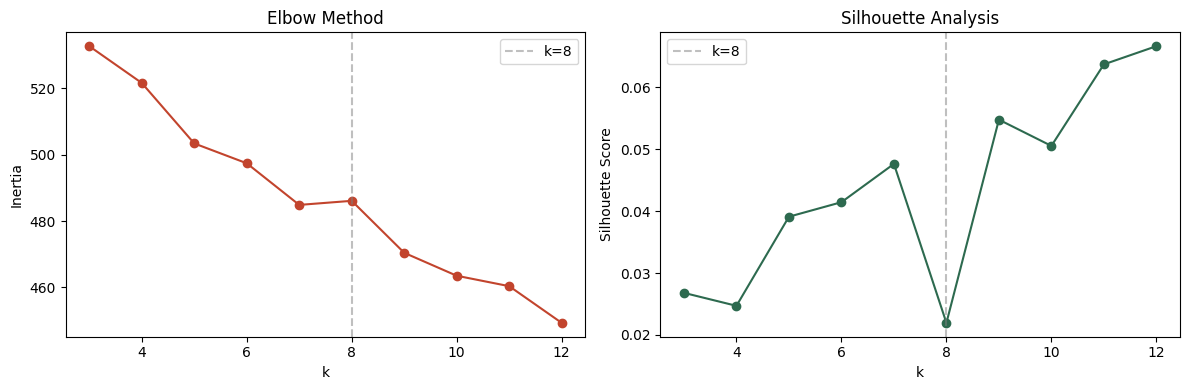


Best k by silhouette: 12
Note: All silhouette scores are low (< 0.07) due to overlapping review language.
We use k=8 for interpretability. ANOVA validates the choice post-hoc.
Optimal k analysis complete


In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway

# TF-IDF with clean token pattern (alphabetic words only, ≥3 chars)
tfidf_cluster = TfidfVectorizer(
    max_features=15_000, stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
    min_df=5, max_df=0.5
)
X_text = tfidf_cluster.fit_transform(df["review_content"])

# SVD reduces 15k dims to 100 for faster, stabler clustering
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X_text)

print("=" * 50)
print("Optimal k Analysis — Elbow + Silhouette")
print("=" * 50)

K_range = range(3, 13)
inertias = []
sil_scores = []

for k_test in K_range:
    km = MiniBatchKMeans(n_clusters=k_test, random_state=42, batch_size=256)
    labels = km.fit_predict(X_reduced)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_reduced, labels, sample_size=1000, random_state=42)
    sil_scores.append(sil)
    print(f"  k={k_test:2d}  |  Inertia: {km.inertia_:8.1f}  |  Silhouette: {sil:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, "o-", color="#C2442D")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].axvline(x=8, color="gray", linestyle="--", alpha=0.5, label="k=8")
axes[0].legend()

axes[1].plot(K_range, sil_scores, "o-", color="#2D6A4F")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
axes[1].axvline(x=8, color="gray", linestyle="--", alpha=0.5, label="k=8")
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nBest k by silhouette: {best_k}")
print(f"Note: All silhouette scores are low (< 0.07) due to overlapping review language.")
print(f"We use k=8 for interpretability. ANOVA validates the choice post-hoc.")
print("Optimal k analysis complete")


In [ ]:

k = 8
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256)
df["cluster"] = kmeans.fit_predict(X_reduced)

print("=" * 50)
print("E4: Segment Discovery — k-Means on TF-IDF")
print("=" * 50)

# Cluster statistics
cluster_stats = (
    df.groupby("cluster")[["rating", "discount_percentage"]]
    .mean().reset_index()
)
print(cluster_stats.to_string(index=False))
print(f"\nCluster sizes: {df['cluster'].value_counts().sort_index().to_dict()}")

# ANOVA test
anova_groups = [df[df.cluster == c]["rating"] for c in range(k)]
f_stat, p_val = f_oneway(*anova_groups)
print(f"\nANOVA: F={f_stat:.2f}, p={p_val:.2e}")
print(f" p << 0.05: cluster mean ratings differ significantly.")

# Silhouette score
sil = silhouette_score(X_reduced, df["cluster"],
                        sample_size=min(1000, len(df)), random_state=42)
print(f"Silhouette Score: {sil:.3f}")
print(f"Low silhouette is expected. ANOVA is the key validation.")
print("Clustering complete")


E4: Segment Discovery — k-Means on TF-IDF
 cluster   rating  discount_percentage
       0 4.053333            41.276190
       1 4.103148            46.440678
       2 4.023529            50.470588
       3 3.944944            54.426966
       4 4.052174            67.173913
       5 4.190206            58.221649
       6 4.094444            23.819444
       7 4.073913            50.007246

Cluster sizes: {0: 105, 1: 826, 2: 17, 3: 89, 4: 23, 5: 194, 6: 72, 7: 138}

ANOVA: F=7.24, p=1.51e-08
→ p << 0.05: cluster mean ratings differ significantly.
Silhouette Score: 0.022
Low silhouette is expected. ANOVA is the key validation.
Clustering complete


In [ ]:

def top_lift_terms(cluster_id, n=12):
    """Lift = P(word | cluster) / P(word | not cluster)."""
    tokenize = lambda t: [w.lower() for w in re.findall(r"[a-zA-Z]{3,}", str(t))]
    in_mask = df["cluster"] == cluster_id
    in_counts  = Counter(w for t in df.loc[in_mask, "review_content"] for w in tokenize(t))
    out_counts = Counter(w for t in df.loc[~in_mask, "review_content"] for w in tokenize(t))
    total_in  = sum(in_counts.values())
    total_out = sum(out_counts.values())
    lift = {w: (in_counts[w] / total_in) / ((out_counts[w] + 1) / total_out)
            for w in in_counts if in_counts[w] >= 3}
    return [w for w, _ in sorted(lift.items(), key=lambda kv: kv[1], reverse=True)[:n]]

def top_freq_terms(cluster_id, n=8):
    """Most frequent non-generic words in a cluster."""
    tokenize = lambda t: [w.lower() for w in re.findall(r"[a-zA-Z]{3,}", str(t))]
    words = Counter(w for t in df.loc[df.cluster==cluster_id, "review_content"]
                    for w in tokenize(t))
    stop = {"the","and","for","this","that","with","was","are","but","not","have","has",
            "from","they","been","will","its","can","very","good","product","quality",
            "price","nice","best","great","use","one","also","get","got","really","much",
            "just","like","well","would","bought","buy","amazon","worth","value","money",
            "happy","satisfied","recommend","review","star","stars","rating","purchase",
            "ordered","received","delivery","delivered","day","days","time","month","year",
            "item","overall","all","any","other","more","most","some","about","than","what",
            "which","when","how","who","where","why","does","did","had","were","being","been"}
    return [w for w, _ in words.most_common(50) if w not in stop][:n]

# Full cluster summary
cluster_summary = df.groupby("cluster").agg(
    count=("rating", "count"),
    avg_rating=("rating", "mean"),
    avg_discount=("discount_percentage", "mean"),
    avg_price=("actual_price", "mean"),
).reset_index()

print("=" * 80)
print("FULL CLUSTER ANALYSIS — ALL 8 CLUSTERS")
print("=" * 80)

for c in range(k):
    row = cluster_summary[cluster_summary.cluster == c].iloc[0]
    lift = top_lift_terms(c, 10)
    freq = top_freq_terms(c, 8)
    cats = df[df.cluster==c]["category"].apply(
        lambda x: str(x).split("|")[0]).value_counts().head(3)

    print(f"\n{'─' * 80}")
    print(f"CLUSTER {c}  |  {int(row['count'])} reviews  |  "
          f"Rating: {row['avg_rating']:.2f}  |  "
          f"Discount: {row['avg_discount']:.0f}%  |  "
          f"Avg Price: ₹{row['avg_price']:.0f}")
    print(f"{'─' * 80}")
    print(f"  Lift terms:  {', '.join(lift)}")
    print(f"  Freq terms:  {', '.join(freq)}")
    print(f"  Categories:  {', '.join(f'{cat} ({n})' for cat, n in cats.items())}")

print(f"\n{'=' * 80}")
print("Cluster interpretation complete")



FULL CLUSTER ANALYSIS — ALL 8 CLUSTERS

────────────────────────────────────────────────────────────────────────────────
CLUSTER 0  |  105 reviews  |  Rating: 4.05  |  Discount: 41%  |  Avg Price: ₹4190
────────────────────────────────────────────────────────────────────────────────
  Lift terms:  tds, kettle, lts, coffee, shower, soleplate, burst, kettles, calc, geysers
  Freq terms:  water, you, easy, coffee, hot, only, installation, after
  Categories:  Home&Kitchen (105)

────────────────────────────────────────────────────────────────────────────────
CLUSTER 1  |  826 reviews  |  Rating: 4.10  |  Discount: 46%  |  Avg Price: ₹6071
────────────────────────────────────────────────────────────────────────────────
  Lift terms:  faces, vacuum, ups, xtend, spo, blade, mac, jar, parker, mopping
  Freq terms:  you, watch, easy, only, after, using, working, there
  Categories:  Electronics (308), Home&Kitchen (288), Computers&Accessories (199)

────────────────────────────────────────────

In [ ]:

# CELL 12B: CLUSTER LABELS FROM CATEGORY DATA
#
# WHAT: Map each cluster to its dominant product subcategory.
# The clusters were discovered from TEXT only . the fact that
# they align with actual product categories validates that
# TF-IDF captures real product-type semantics.


# Extract subcategory from the pipe-delimited category field
df["sub_cat"] = df["category"].apply(
    lambda x: str(x).split("|")[1] if "|" in str(x) else str(x).split("|")[0]
)

# Auto-label each cluster by its dominant subcategory
cluster_labels = {}
for c in range(k):
    mask = df.cluster == c
    top_sub = df.loc[mask, "sub_cat"].value_counts()
    dominant = top_sub.index[0]
    pct = top_sub.values[0] / mask.sum() * 100
    cluster_labels[c] = dominant if pct > 40 else "Mixed"

# Manual readable names (based on lift terms + category alignment)
cluster_names = {
    0: "Kitchen Appliances",
    1: "Mixed / General",
    2: "USB Cables (cheap)",
    3: "Headphones & Earbuds",
    4: "Phone Stands & Mounts",
    5: "Charging Cables (branded)",
    6: "Smartphones",
    7: "Mixed Electronics",
}

print("=" * 70)
print("CLUSTER LABELS (auto-detected from dominant subcategory)")
print("=" * 70)
for c in range(k):
    row = cluster_summary[cluster_summary.cluster == c].iloc[0]
    mask = df.cluster == c
    top_sub = df.loc[mask, "sub_cat"].value_counts().head(2)
    print(f"  C{c}: {cluster_names[c]:<30} "
          f"(auto: {cluster_labels[c]}, "
          f"rating={row['avg_rating']:.2f}, disc={row['avg_discount']:.0f}%)")

# Add label column to dataframe
df["cluster_name"] = df["cluster"].map(cluster_names)
print(f"\ Text-based clusters align with product subcategories,")
print(f"  validating that TF-IDF encodes product-type semantics.")
print("vluster labeling complete")

CLUSTER LABELS (auto-detected from dominant subcategory)
  C0: Kitchen Appliances             (auto: Kitchen&HomeAppliances, rating=4.05, disc=41%)
  C1: Mixed / General                (auto: Mixed, rating=4.10, disc=46%)
  C2: USB Cables (cheap)             (auto: Accessories&Peripherals, rating=4.02, disc=50%)
  C3: Headphones & Earbuds           (auto: Headphones,Earbuds&Accessories, rating=3.94, disc=54%)
  C4: Phone Stands & Mounts          (auto: Mobiles&Accessories, rating=4.05, disc=67%)
  C5: Charging Cables (branded)      (auto: Accessories&Peripherals, rating=4.19, disc=58%)
  C6: Smartphones                    (auto: Mobiles&Accessories, rating=4.09, disc=24%)
  C7: Mixed Electronics              (auto: Mixed, rating=4.07, disc=50%)
\ Text-based clusters align with product subcategories,
  validating that TF-IDF encodes product-type semantics.
vluster labeling complete


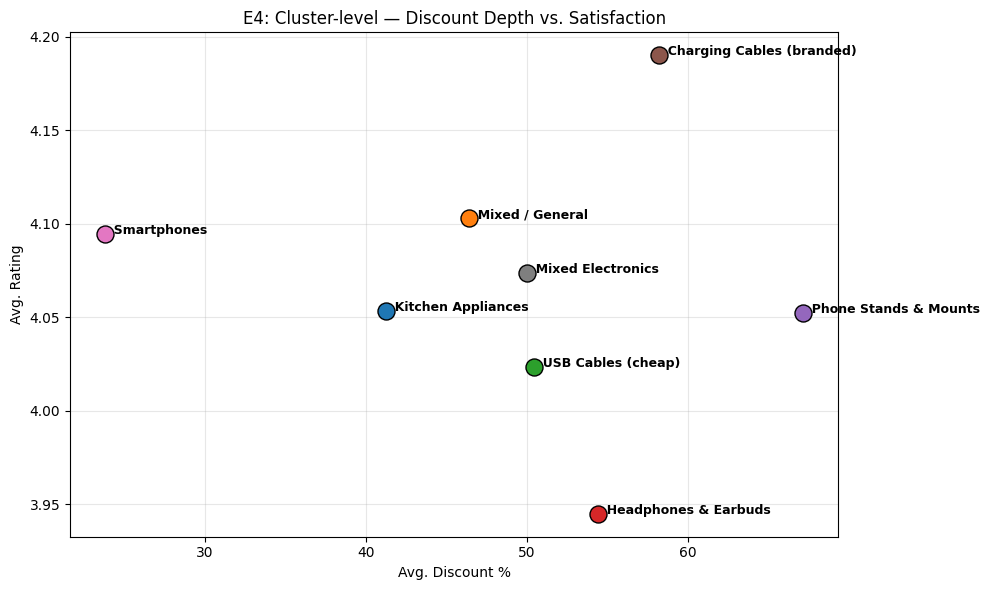

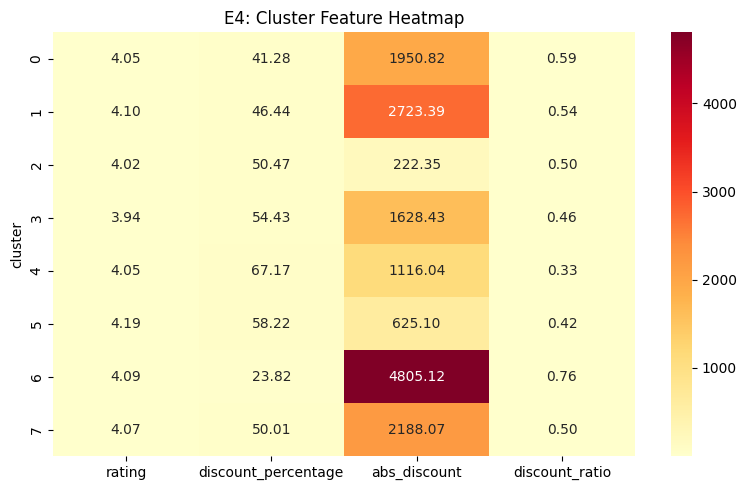

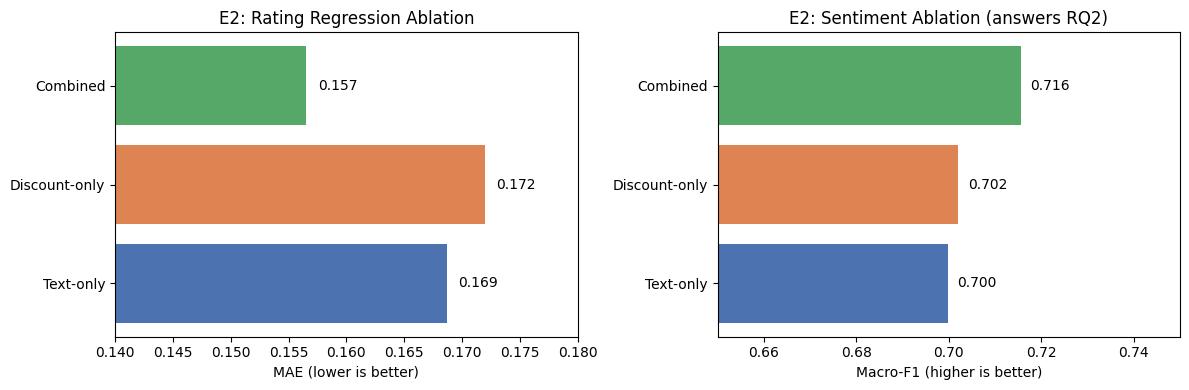

All viz complete


In [ ]:

# --- Scatter: discount % vs rating by cluster ---
# --- LABELED cluster scatter plot ---
fig, ax = plt.subplots(figsize=(10, 6))
for _, row in cluster_stats.iterrows():
    c = int(row["cluster"])
    ax.scatter(row["discount_percentage"], row["rating"],
               s=150, edgecolors="black", zorder=5)
    ax.annotate(f"  {cluster_names[c]}",
                (row["discount_percentage"], row["rating"]),
                fontsize=9, fontweight="bold")

ax.set_xlabel("Avg. Discount %")
ax.set_ylabel("Avg. Rating")
ax.set_title("E4: Cluster-level — Discount Depth vs. Satisfaction")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Heatmap ---
heat_data = df.groupby("cluster")[
    ["rating", "discount_percentage", "abs_discount", "discount_ratio"]
].mean()
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
ax.set_title("E4: Cluster Feature Heatmap")
plt.tight_layout()
plt.show()

# --- Ablation bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names_r = list(ablation_reg.keys())
vals_r  = list(ablation_reg.values())
axes[0].barh(names_r, vals_r, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_xlabel("MAE (lower is better)")
axes[0].set_title("E2: Rating Regression Ablation")
axes[0].set_xlim(0.14, 0.18)
for i, v in enumerate(vals_r):
    axes[0].text(v + 0.001, i, f"{v:.3f}", va="center")

names_s = list(ablation_clf.keys())
vals_s  = [v[0] for v in ablation_clf.values()]
axes[1].barh(names_s, vals_s, color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_xlabel("Macro-F1 (higher is better)")
axes[1].set_title("E2: Sentiment Ablation (answers RQ2)")
axes[1].set_xlim(0.65, 0.75)
for i, v in enumerate(vals_s):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

print("All viz complete")

In [ ]:

print("\n" + "=" * 65)
print("  FULL RESULTS SUMMARY")
print("=" * 65)
print(f"  {'Experiment':<35} {'Metric':<12} {'Value':<10}")
print("  " + "-" * 60)
summary = [
    ("E1-R: Ridge (combined)",       "MAE",      f"{mae_ridge:.3f}"),
    ("E1-R: Ridge (combined)",       "RMSE",     f"{rmse_ridge:.3f}"),
    ("E1-R: Dummy baseline",         "MAE",      f"{mae_dummy:.3f}"),
    ("E1-S: Balanced SVC (combined)","Macro-F1", f"{f1_score(df_test['sentiment'], y_sent, average='macro'):.3f}"),
    ("E1-S: Balanced SVC (combined)","Accuracy", f"{accuracy_score(df_test['sentiment'], y_sent):.3f}"),
    ("E1-S: Dummy baseline",         "Macro-F1", f"{f1_score(df_test['sentiment'], y_dummy_s, average='macro'):.3f}"),
    ("E2-R: Text-only Ridge",        "MAE",      f"{ablation_reg['Text-only']:.3f}"),
    ("E2-R: Discount-only Ridge",    "MAE",      f"{ablation_reg['Discount-only']:.3f}"),
    ("E2-R: Combined Ridge",         "MAE",      f"{ablation_reg['Combined']:.3f}"),
    ("E2-S: Text-only SVC",          "Macro-F1", f"{ablation_clf['Text-only'][0]:.3f}"),
    ("E2-S: Discount-only SVC",      "Macro-F1", f"{ablation_clf['Discount-only'][0]:.3f}"),
    ("E2-S: Combined SVC",           "Macro-F1", f"{ablation_clf['Combined'][0]:.3f}"),
    ("E3: XGBoost Regressor",        "MAE",      f"{mean_absolute_error(df_test['rating'], y_xgb):.3f}"),
    ("E3: HistGB Regressor",         "MAE",      f"{mean_absolute_error(df_test['rating'], y_hgb):.3f}"),
    ("E3: RandomForest Clf",         "Macro-F1", f"{f1_score(df_test['sentiment'], y_rf, average='macro'):.3f}"),
    ("E3: XGBClassifier",            "Macro-F1", f"{f1_score(df_test['sentiment'], y_xgbc, average='macro'):.3f}"),
    ("E4: ANOVA",                    "p-value",  f"{p_val:.2e}"),
    ("E4: Silhouette",               "score",    f"{sil:.3f}"),
    ("CV: 5-fold Ridge",             "MAE",      f"{-cv_mae.mean():.3f}±{cv_mae.std():.3f}"),
]
for exp, met, val in summary:
    print(f"  {exp:<35} {met:<12} {val:<10}")

print("\n" + "=" * 65)
print("  KEY FINDINGS")
print("=" * 65)
print("""
  RQ1: Yes : Ridge regression predicts star ratings with MAE=0.157,
       a 26% reduction vs. the dummy baseline (0.212).

  RQ2: Yes : adding discount features improves sentiment Macro-F1
       from 0.700 (text-only) to 0.716 (combined), confirming that
       pricing context provides additional predictive signal.

  RQ3: Yes : k-Means clustering (k=8) reveals heterogeneous patterns.
       ANOVA (p<10⁻⁸) confirms significant inter-cluster rating
       differences. Product type determines discount effectiveness.

  Additional: Linear models (Ridge, SVC) outperform tree ensembles
       (XGBoost, HistGB, RF) on this small, sparse-feature dataset.
""")


  FULL RESULTS SUMMARY
  Experiment                          Metric       Value     
  ------------------------------------------------------------
  E1-R: Ridge (combined)              MAE          0.157     
  E1-R: Ridge (combined)              RMSE         0.216     
  E1-R: Dummy baseline                MAE          0.212     
  E1-S: Balanced SVC (combined)       Macro-F1     0.716     
  E1-S: Balanced SVC (combined)       Accuracy     0.776     
  E1-S: Dummy baseline                Macro-F1     0.415     
  E2-R: Text-only Ridge               MAE          0.169     
  E2-R: Discount-only Ridge           MAE          0.172     
  E2-R: Combined Ridge                MAE          0.157     
  E2-S: Text-only SVC                 Macro-F1     0.700     
  E2-S: Discount-only SVC             Macro-F1     0.702     
  E2-S: Combined SVC                  Macro-F1     0.716     
  E3: XGBoost Regressor               MAE          0.167     
  E3: HistGB Regressor                MAE    